In [1]:
import sys
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Add dirctory with model moduels to path
sys.path.insert(0, os.path.join(os.getcwd(),'..'))

import CIBUSmod as cm
from CIBUSmod.utils.output_data_manip import concat_herds

# Create input data
x0_crp.csv and x0_ani.csv represent the current areas of different crops and number of heads of different animals respectively. These are both still WIP, which is why some mangling is needed here to get them in the right form.
The demand vector is generated with demand for cattle meat, pig meat and cattle milk equal to what is in the agricultural statistics.

In [2]:
# Define x0_crp
x0_crp = \
    pd.read_csv(os.path.join('..','data','x0','x0_crp.csv'), dtype={'region': object})\
    .set_index(['crop','prod_system','region'])['area']

# Define x0_ani
x0_ani = pd.read_csv(os.path.join('..','data','x0','x0_ani.csv'), dtype={'region': object})

x0_ani['species'] = np.nan
x0_ani['species'] = \
np.where(np.isin(x0_ani['animal'], ['kor för mjölkproduktion', 'kor för uppfödning av kalvar']),'cattle',x0_ani['species'])
x0_ani['species'] = \
np.where(x0_ani['animal']=='suggor för avel','pigs',x0_ani['species'])

x0_ani['breed'] = np.nan
x0_ani['breed'] = \
np.where(x0_ani['animal']=='kor för mjölkproduktion','dairy',x0_ani['breed'])
x0_ani['breed'] = \
np.where(x0_ani['animal']=='kor för uppfödning av kalvar','beef',x0_ani['breed'])
x0_ani['breed'] = \
np.where(x0_ani['animal']=='suggor för avel','none',x0_ani['breed'])

x0_ani = x0_ani[x0_ani['species']!='nan'][['species','breed','prod_system','region','number']].set_index(['species','breed','prod_system','region'])['number']

x0_ani = x0_ani.fillna(0)

x0 = {'ani':x0_ani,'crp':x0_crp}

In [3]:
# Create demand vectors
# Animal products
D_ani = pd.Series(
    {
        ('conventional','cattle','meat') : (136-21) * 1000000,
        ('organic','cattle','meat')      : 21 * 1000000,
        ('conventional','cattle','milk') : (2760-464) * 1000000,
        ('organic','cattle','milk')      : 464 * 1000000,
        ('conventional','pigs','meat')   : (249-6) * 1000000,
        ('organic','pigs','meat')        : 6 * 1000000,
    },
)
D_ani.index.rename(['prod_system','species','product'], inplace=True)

# Crop products (kg DM)
D_crp = pd.Series(
    {
        ('conventional','wheat')         :0,
        ('organic','wheat')              :0,
    },
)
D_crp.index.rename(['prod_system','crop_product'], inplace=True)

D = {'ani':D_ani, 'crp':D_crp}

# Run base year
This runs the model for the base year (2016-2020). Results are then compared to statistics to ensure feasible results replicating the current situation.

In [4]:
# Instantiate crop production
crops = cm.CropProduction(
    par = cm.ParameterRetriever(
        os.path.join('..','data','prod_parameters','CropProduction.xlsx')
    ),
    index = x0_crp.index
)    

# Instantiate animal herds
herds=pd.Series(
    data=[],
    index=pd.MultiIndex(
        levels=[[]]*4,
        codes=[[]]*4,
        names=['species','breed','prod_system','sub_system']
    ),
    dtype = object
)

for (sp,br,ps) in x0_ani.groupby(['species','breed','prod_system']).sum().index:
            
    if sp == 'cattle':
        herds[(sp,br,ps,'none')] = \
            cm.CattleHerd(
                par = cm.ParameterRetriever(
                    os.path.join('..','data','prod_parameters','CattleHerd.xlsx')
                ),
                index = x0_ani.index.get_level_values('region').unique(),
                breed = br,
                prod_system = ps
            )

    elif sp == 'pigs':
        herds[(sp,br,ps,'none')] = \
            cm.PigHerd(
                par = cm.ParameterRetriever(
                    os.path.join('..','data','prod_parameters','PigHerd.xlsx')
                ),
                index = x0_ani.index.get_level_values('region').unique(),
                breed = br,
                prod_system = ps
            ) 

# Instantiate manure management
feed_mgmt = cm.FeedMgmt(
    herds = herds,
    par = cm.ParameterRetriever(
        os.path.join('..','data','prod_parameters','FeedMgmt.xlsx')
    )
)

# Instantiate manure management
manure_mgmt = cm.ManureMgmt(
    herds = herds,
    par = cm.ParameterRetriever(
        os.path.join('..','data','prod_parameters','ManureMgmt.xlsx')
    )
)

# Instantiate geo distributor
geodist = cm.GeoDistributor(D,x0,crops,herds,feed_mgmt)

# -------------------------------------------------------------------- #

# Calculate crops
crops.calculate(
    verbose = True
)

# Calculate herds
for h in herds:
    h.calculate(verbose = True)

# Calculate feed
feed_mgmt.calculate(verbose=True)    

# Calculate manure
manure_mgmt.calculate(verbose=True)

[15:03:13][CropProduction] Calculating harvest ...
[15:03:13][CropProduction] Calculating production ...


C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\notebooks\..\CIBUSmod\utils\retriever.py:163: UserWarning: NaNs returned! No value for 'yield' found in '..\data\prod_parameters\CropProduction.xlsx' for some of the supplied filters (n=503): 
----------
f_crop = Beans, dry 
f_prod_system = conventional
f_region = 1011
----------
f_crop = Beans, dry 
f_prod_system = conventional
f_region = 111
----------
f_crop = Beans, dry 
f_prod_system = conventional
f_region = 1111
----------
f_crop = Beans, dry 
f_prod_system = conventional
f_region = 1112
----------
f_crop = Beans, dry 
f_prod_system = conventional
f_region = 112
 ...
  warnings.warn(str1+str2)


[15:03:13][CropProduction] Done! Elapsed time: 0 sec
[15:03:13][AnimalHerd (cattle, beef, conventional, none)] Calculating herd structure ...
[15:03:14][AnimalHerd (cattle, beef, conventional, none)] Calculating production ...
[15:03:14][AnimalHerd (cattle, beef, conventional, none)] Done! Elapsed time: 0 sec
[15:03:14][AnimalHerd (cattle, beef, organic, none)] Calculating herd structure ...
[15:03:14][AnimalHerd (cattle, beef, organic, none)] Calculating production ...
[15:03:14][AnimalHerd (cattle, beef, organic, none)] Done! Elapsed time: 1 sec
[15:03:14][AnimalHerd (cattle, dairy, conventional, none)] Calculating herd structure ...
[15:03:15][AnimalHerd (cattle, dairy, conventional, none)] Calculating production ...
[15:03:15][AnimalHerd (cattle, dairy, conventional, none)] Done! Elapsed time: 0 sec
[15:03:15][AnimalHerd (cattle, dairy, organic, none)] Calculating herd structure ...
[15:03:15][AnimalHerd (cattle, dairy, organic, none)] Calculating production ...
[15:03:15][AnimalHe

C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\notebooks\..\CIBUSmod\utils\retriever.py:151: UserWarning: NaNs returned! No value for 'slaughter_weight' found in '..\data\prod_parameters\PigHerd.xlsx' matching any of the supplied filters (n=1): 
----------
f_prod_system = conventional
f_animal = piglets
  warnings.warn(str1+str2)
C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\notebooks\..\CIBUSmod\utils\retriever.py:151: UserWarning: NaNs returned! No value for 'slaughter_weight' found in '..\data\prod_parameters\PigHerd.xlsx' matching any of the supplied filters (n=1): 
----------
f_prod_system = conventional
f_animal = gilts
  warnings.warn(str1+str2)
C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\notebooks\..\CIBUSmod\utils\retriever.py:151: UserWarning: NaNs returned! No value for 'slaughter_weight' found in '..\data\prod_parameters\PigHerd.xlsx' match

[15:03:16][AnimalHerd (pigs, none, conventional, none)] Done! Elapsed time: 0 sec
[15:03:16][AnimalHerd (pigs, none, organic, none)] Calculating herd structure ...
[15:03:16][AnimalHerd (pigs, none, organic, none)] Calculating production ...
[15:03:16][AnimalHerd (pigs, none, organic, none)] Done! Elapsed time: 0 sec
[15:03:16][FeedMgmt] Calculating feed consumption ...


C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\notebooks\..\CIBUSmod\utils\retriever.py:151: UserWarning: NaNs returned! No value for 'live_weight' found in '..\data\prod_parameters\CattleHerd.xlsx' matching any of the supplied filters (n=1): 
----------
f_breed = beef
f_prod_system = conventional
f_sub_system = none
f_animal = breeding bulls
  warnings.warn(str1+str2)
C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\notebooks\..\CIBUSmod\utils\retriever.py:151: UserWarning: NaNs returned! No value for 'live_weight' found in '..\data\prod_parameters\CattleHerd.xlsx' matching any of the supplied filters (n=1): 
----------
f_breed = beef
f_sub_system = none
f_prod_system = organic
f_animal = breeding bulls
f_from_ps = organic
f_to_ps = conventional
  warnings.warn(str1+str2)
C:\Users\jnka0003\Documents\#1 Projekt\MISTRA Food Futures WP5\CIBUSmod Food Systems Model\notebooks\..\CIBUSmod\utils\retriever.p

[15:03:21][FeedMgmt] Calculating demand for crop products ...
[15:03:22][FeedMgmt] Calculating demand for by-products ...
[15:03:23][FeedMgmt] Done! Elapsed time: 7 sec
[15:03:23][ManureMgmt] Calculating N excretion ...
[15:03:24][ManureMgmt] Calculating N losses ...
[15:03:29][ManureMgmt] Calculating N available to spread ...
[15:03:29][ManureMgmt] Done! Elapsed time: 6 sec


In [5]:
# Distribute animals and crops
geodist.make(use_cons=[1,2,3,4],verbose=True)


[15:03:29][GeoDist.make] Making constraint C1 ...
[15:03:31][GeoDist.make] Making constraint C2 ...
[15:04:39][GeoDist.make] Making constraint C3 ...
[15:04:39][GeoDist.make] Making constraint C4 ...
[15:04:39][GeoDist.make] Making objective O1 ...
[15:04:40][GeoDist.make] Defining problem ...
[15:04:40][GeoDist.make] Done! Elapsed time: 70 sec


In [6]:
geodist.solve(verbose=True)

[15:04:40][GeoDist.solve] Finding solution ...
[15:04:49][GeoDist.solve] Optimal solution found! Status: 'optimal', Solver: 'OSQP'
[15:04:49][GeoDist.solve] Done! Elapsed time: 9 sec


In [19]:
geodist.solve(
    verbose=True,
    solver_settings = {
        'solver':'OSQP',
        'max_iter':200000,
        'eps_abs':1e-6,
        'eps_rel':1e-6,
        'verbose':True
    }
)

[15:09:33][GeoDist.solve] Finding solution ...
                                     CVXPY                                     
                                     v1.3.0                                    
(CVXPY) Apr 21 03:09:33 PM: Your problem has 12084 variables, 4 constraints, and 0 parameters.
(CVXPY) Apr 21 03:09:33 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Apr 21 03:09:33 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Apr 21 03:09:33 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Apr 21 03:09:33 PM: Compiling problem (target solver=OSQP).
(CVXPY) Apr 21 03:09:33 PM: Reduction chain: C

17600   1.2910e+09   3.97e+01   9.35e+00   5.70e-04   1.35e+01s
17800   1.2910e+09   3.90e+01   9.30e+00   5.70e-04   1.37e+01s
18000   1.2910e+09   3.87e+01   9.24e+00   5.70e-04   1.38e+01s
18200   1.2910e+09   3.84e+01   9.19e+00   5.70e-04   1.40e+01s
18400   1.2910e+09   3.81e+01   9.14e+00   5.70e-04   1.41e+01s
18600   1.2910e+09   3.79e+01   9.09e+00   5.70e-04   1.43e+01s
18800   1.2910e+09   3.76e+01   8.99e+00   5.70e-04   1.44e+01s
19000   1.2909e+09   3.74e+01   8.93e+00   5.70e-04   1.46e+01s
19200   1.2909e+09   3.39e+01   8.86e+00   5.70e-04   1.47e+01s
19400   1.2909e+09   3.14e+01   7.00e+00   5.70e-04   1.49e+01s
19600   1.2909e+09   2.87e+01   3.51e+00   5.70e-04   1.50e+01s
19800   1.2909e+09   2.62e+01   1.74e+00   5.70e-04   1.52e+01s
20000   1.2908e+09   2.61e+01   8.56e-01   5.70e-04   1.53e+01s
20200   1.2908e+09   2.60e+01   4.22e-01   5.70e-04   1.55e+01s
20400   1.2908e+09   2.60e+01   2.08e-01   5.70e-04   1.57e+01s
20600   1.2908e+09   2.60e+01   1.02e-01

In [20]:
geodist.problem.value

1290702162.7336543

In [21]:
# Scale and store results
out_crops = crops.scale(geodist.x['crp'])

out_animals = concat_herds([
    h.scale(
        geodist.x['ani'].loc[(h.species,h.breed,h.prod_system,h.sub_system)],
        x_is = h.x_is
    )
    for h in herds
])

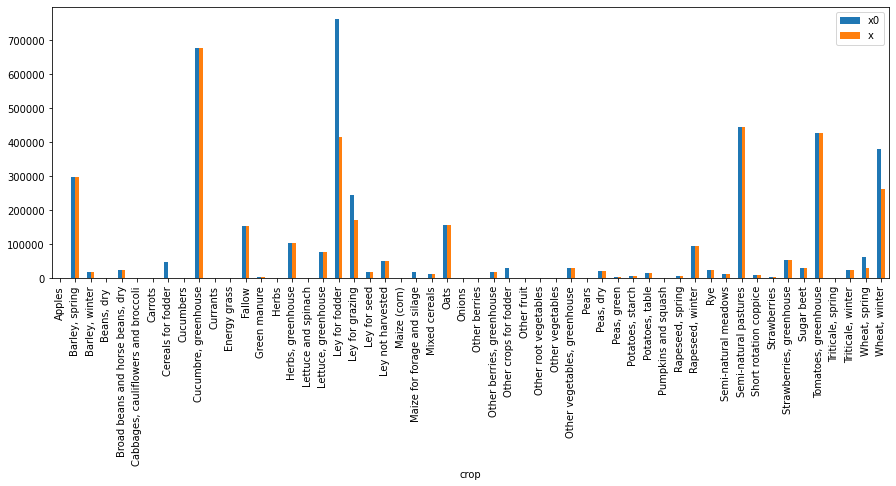

In [22]:
fig, ax = plt.subplots(figsize=(15,5))

pd.concat([
    x0_crp.groupby('crop').sum().rename('x0'),
    out_crops.area.groupby('crop').sum().rename('x')
], axis=1).plot.bar(ax=ax)

plt.show()

In [23]:
idx = pd.IndexSlice

print(
    pd.concat([
        out_animals.heads
        .groupby(['species','breed','prod_system','animal'], axis=1).sum()
        .sum().loc[idx[:,:,:,['cows','sows']]].droplevel('animal')
        .rename('x')
        ,
        x0_ani
        .groupby(['species','breed','prod_system']).sum()
        .rename('x0')
    ], axis=1)
    .apply(
        lambda x:
        pd.Series(
            [x['x'].round(1),x['x0'].round(1),((x['x']-x['x0'])/x['x0']*100).round(1)],
            index = ['x','x0','% dif']
        ),
        axis=1
    )
)

print(
    pd.concat([
        out_crops.area.groupby('crop').sum().rename('x'),
        x0_crp.groupby('crop').sum().rename('x0')
    ], axis=1)
    .apply(
        lambda x:
        pd.Series(
            [x['x'].round(1),x['x0'].round(1),((x['x']-x['x0'])/x['x0']*100).round(1)],
            index = ['x','x0','% dif']
        ),
        axis=1
    )
)

                                   x        x0  % dif
species breed prod_system                            
cattle  beef  conventional  151637.6  128080.1   18.4
              organic        54762.2   72274.4  -24.2
        dairy conventional  246516.6  263227.4   -6.3
              organic        54567.6   54920.6   -0.6
pigs    none  conventional  101749.5  132262.5  -23.1
              organic         3452.4    3325.0    3.8
                                            x        x0  % dif
crop                                                          
Apples                                 1598.0    1552.0    3.0
Barley, spring                       296999.3  296954.7    0.0
Barley, winter                        18488.3   18442.5    0.2
Beans, dry                              749.4     703.3    6.6
Broad beans and horse beans, dry      25109.6   25063.8    0.2
Cabbages, cauliflowers and broccoli    1514.1    1468.5    3.1
Carrots                                1806.1    1760.5    2.6
C